# SW Correction QA — Elevation × Aspect Heatmap

Loads one year of remapped SUMMA forcing, applies the DAH SW correction, and shows mean SWRadAtm by elevation × aspect band.

In [1]:
from pathlib import Path
import sys, logging
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import yaml

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'CONFLUENCE.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.models.summa_utils import SummaPreProcessor

# ── Controls ──────────────────────────────────────────────────────
CONFIG_PATH = (REPO_ROOT / 'ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml').resolve()
YEAR        = 2000          # year to load (12 monthly files)
APPLY_DAH   = True          # toggle DAH SW correction on/off

In [15]:
def make_logger(name='sw-qa'):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers = []
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
    logger.propagate = False
    return logger


def load_config(path):
    with path.open('r') as f:
        return yaml.safe_load(f)


def find_forcing_files(config, year):
    """Return sorted list of SUMMA-input netCDF files for the given year."""
    project_dir = Path(config['CONFLUENCE_DATA_DIR']) / f"domain_{config['DOMAIN_NAME']}"
    search_dirs = [
        project_dir / 'forcing' / 'SUMMA_input',
        project_dir / 'forcing' / 'basin_averaged_data',
    ]
    files = []
    for d in search_dirs:
        if d.exists():
            files.extend(sorted(d.glob(f'*{year}*.nc')))
    if not files:
        raise FileNotFoundError(f'No forcing files found for year {year} in {search_dirs}')
    return files


def load_year(files, pre, apply_dah):
    """Load all monthly files for one year, optionally applying DAH SW correction."""
    chunks = []
    for f in files:
        with xr.open_dataset(f, decode_times=False) as ds:
            ds_part = ds[['SWRadAtm']].copy()
            # resolve hruId — store as coordinate so it stays 1-D after xr.concat
            for src in [ds, ds.coords]:
                if 'hruId' in src:
                    hru_id_vals = np.asarray(src['hruId']).astype(int)
                    break
            else:
                hru_id_vals = np.arange(ds_part.sizes['hru'], dtype=int) + 1
            ds_part = ds_part.assign_coords(hruId=('hru', hru_id_vals))
            ds_part = ds_part.load()

        if apply_dah:
            ds_part = pre._apply_aspect_shortwave_correction(ds_part, f.name)
        chunks.append(ds_part)
    return xr.concat(chunks, dim='time')


def sw_by_elev_aspect(ds, gdf, hru_col, area_col, elev_col, aspect_col, aspect_class_map):
    """Area-weighted mean SWRadAtm per elevation × aspect band."""
    hru_ids = ds['hruId'].values.astype(int)
    sw_mean = ds['SWRadAtm'].mean(dim='time', skipna=True).values

    lookup = gdf[[hru_col, area_col, elev_col, aspect_col]].copy()
    lookup[hru_col] = pd.to_numeric(lookup[hru_col], errors='coerce').astype('Int64').astype(int)

    frame = pd.DataFrame({hru_col: hru_ids, 'sw': sw_mean})
    frame = frame.merge(lookup, on=hru_col, how='left')
    frame['aspect4'] = frame[aspect_col].map(aspect_class_map).fillna(frame[aspect_col].astype(str))
    frame['elev_band'] = pd.to_numeric(frame[elev_col], errors='coerce').astype('Int64')
    frame['w'] = pd.to_numeric(frame[area_col], errors='coerce').fillna(1.0).clip(lower=1.0)

    rows = []
    for (e, a), sub in frame.dropna(subset=['elev_band', 'aspect4', 'sw']).groupby(['elev_band', 'aspect4']):
        rows.append({
            'elev_band': int(e), 'aspect': str(a),
            'SW_mean': float(np.average(sub['sw'], weights=sub['w'])),
        })
    return pd.DataFrame(rows).sort_values(['elev_band', 'aspect']).reset_index(drop=True)


def plot_heatmap(df, title, cmap='viridis'):
    aspect_order = ['NE', 'SE', 'SW', 'NW']
    df = df[df['aspect'].isin(aspect_order)]
    elev_order = sorted(df['elev_band'].unique(), reverse=True)

    pivot = (
        df.pivot(index='elev_band', columns='aspect', values='SW_mean')
        .reindex(index=elev_order, columns=aspect_order)
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    img = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(aspect_order)), labels=aspect_order)
    ax.set_yticks(range(len(elev_order)), labels=[f'Elev {b}' for b in elev_order])
    ax.set_xlabel('Aspect')
    ax.set_ylabel('Elevation band')
    ax.set_title(title)
    for i in range(len(elev_order)):
        for j in range(len(aspect_order)):
            v = pivot.iloc[i, j]
            ax.text(j, i, 'NA' if pd.isna(v) else f'{v:.1f}', ha='center', va='center',
                    color='white', fontsize=9)
    fig.colorbar(img, ax=ax, shrink=0.9, label='Mean SWRadAtm (W m⁻²)')
    plt.tight_layout()
    plt.show()


def infer_aspect_labels(gdf, pre, hru_col, aspect_col):
    """Return dict mapping integer aspect class → direction string (NE/SE/SW/NW)."""
    hru_ids = pd.to_numeric(gdf[hru_col], errors='coerce').dropna().astype(int).unique()
    aspect_deg, _, _ = pre._get_aspect_sw_arrays(hru_ids)
    tmp = pd.DataFrame({hru_col: hru_ids, 'aspect_deg': aspect_deg})
    cls = gdf[[hru_col, aspect_col]].copy()
    cls[hru_col] = pd.to_numeric(cls[hru_col], errors='coerce').astype('Int64').dropna().astype(int)
    merged = tmp.merge(cls, on=hru_col, how='inner').dropna()
    merged[aspect_col] = pd.to_numeric(merged[aspect_col], errors='coerce')

    labels = {1: 'NE', 2: 'SE', 3: 'SW', 4: 'NW', 0: 'Flat'}
    class_map = {}
    for class_id, sub in merged.groupby(aspect_col):
        cid = int(class_id)
        if cid in labels:
            class_map[cid] = labels[cid]
    return class_map

In [16]:
logger  = make_logger()
config  = load_config(CONFIG_PATH)
config['APPLY_ASPECT_SW_CORRECTION'] = APPLY_DAH  # pass toggle into preprocessor
pre     = SummaPreProcessor(config, logger)

catchment_file = pre.catchment_path / pre.catchment_name
gdf = gpd.read_file(catchment_file)

hru_col    = config.get('CATCHMENT_SHP_HRUID', 'HRU_ID')
area_col   = next((c for c in [config.get('CATCHMENT_SHP_AREA', 'HRU_area'), 'HRU_area', 'area'] if c in gdf.columns), None)
elev_col   = next((c for c in ['elevClass', 'elevClas'] if c in gdf.columns), None)
aspect_col = next((c for c in ['aspectClass', 'aspectClas'] if c in gdf.columns), None)

aspect_class_map = infer_aspect_labels(gdf, pre, hru_col, aspect_col)
forcing_files    = find_forcing_files(config, YEAR)

print(f'Catchment : {catchment_file.name}  ({len(gdf)} HRUs)')
print(f'Forcing   : {len(forcing_files)} files for {YEAR}')
print(f'Aspect map: {aspect_class_map}')
print(f'DAH on    : {APPLY_DAH}')

[INFO] Calculating aspect from DEM for each HRU
[INFO] Calculating tangent of slope from DEM for each HRU


Catchment : East_River_distributed_elevAspect_HRUs_elevation_aspect.shp  (25 HRUs)
Forcing   : 24 files for 2000
Aspect map: {0: 'Flat', 1: 'NE', 2: 'SE', 3: 'SW', 4: 'NW'}
DAH on    : True


In [14]:
(ds_dah-ds_raw).mean(dim='time')['SWRadAtm']

<xarray.DataArray 'SWRadAtm' (hru: 25)> Size: 100B
array([-92.53463  ,  38.197746 , -41.57794  ,  90.32858  , -24.392029 ,
       -88.75415  ,  27.736792 , -29.054974 ,  75.38652  ,  10.532158 ,
       -78.82081  ,  21.123535 , -31.23815  ,  61.641663 ,   4.1728873,
       -69.34919  ,  20.690905 , -32.64252  ,  53.65316  ,   8.785724 ,
       -53.466244 ,  11.285429 , -25.687187 ,  36.662773 ,   3.615304 ],
      dtype=float32)
Dimensions without coordinates: hru

[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200001.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200002.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200003.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200004.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200005.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200006.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200007.nc: Applied DAH SW correction (scaling=1.0, range [0.553, 1.436])
[INFO]

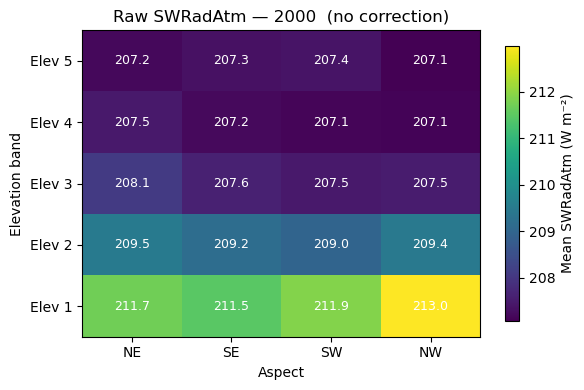

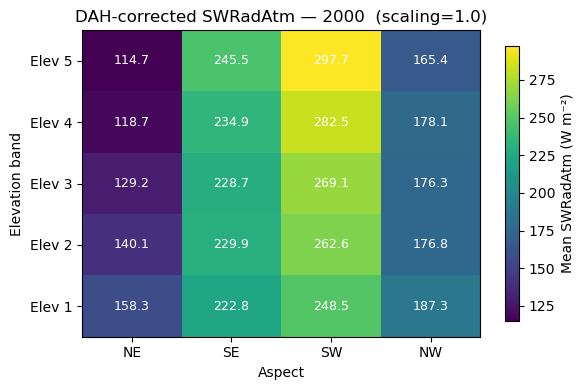

 elev_band aspect  SW_mean_raw  SW_mean_dah    ratio
         1   Flat   213.141785   216.758133 1.016967
         1     NE   211.712631   158.259293 0.747519
         1     NW   212.997955   187.294998 0.879328
         1     SE   211.488098   222.787537 1.053428
         1     SW   211.892212   248.464600 1.172599
         2   Flat   209.211700   217.997757 1.041996
         2     NE   209.473541   140.088242 0.668763
         2     NW   209.445801   176.824371 0.844249
         2     SE   209.168808   229.860809 1.098925
         2     SW   208.978546   262.631409 1.256739
         3   Flat   207.681274   211.854202 1.020093
         3     NE   208.053497   129.194504 0.620968
         3     NW   207.501297   176.283264 0.849553
         3     SE   207.594482   228.725189 1.101788
         3     SW   207.459167   269.116882 1.297204
         4   Flat   207.394867   217.927185 1.050784
         4     NE   207.467850   118.676659 0.572024
         4     NW   207.111328   178.068573 0.

In [17]:
# Load 1 year of forcing and plot mean SW by elevation × aspect
ds_raw = load_year(forcing_files, pre, apply_dah=False)
ds_dah = load_year(forcing_files, pre, apply_dah=True)

agg_raw = sw_by_elev_aspect(ds_raw, gdf, hru_col, area_col, elev_col, aspect_col, aspect_class_map)
agg_dah = sw_by_elev_aspect(ds_dah, gdf, hru_col, area_col, elev_col, aspect_col, aspect_class_map)

plot_heatmap(agg_raw, f'Raw SWRadAtm — {YEAR}  (no correction)')
plot_heatmap(agg_dah, f'DAH-corrected SWRadAtm — {YEAR}  (scaling={config.get("DAH_SCALING_FACTOR", 1.0)})')

# Ratio: DAH / raw per band
ratio_df = agg_raw.merge(agg_dah, on=['elev_band', 'aspect'], suffixes=('_raw', '_dah'))
ratio_df['ratio'] = ratio_df['SW_mean_dah'] / ratio_df['SW_mean_raw']
print(ratio_df[['elev_band', 'aspect', 'SW_mean_raw', 'SW_mean_dah', 'ratio']].to_string(index=False))